#CUSTOMIZING UTKFace Dataset w/ Pytorch

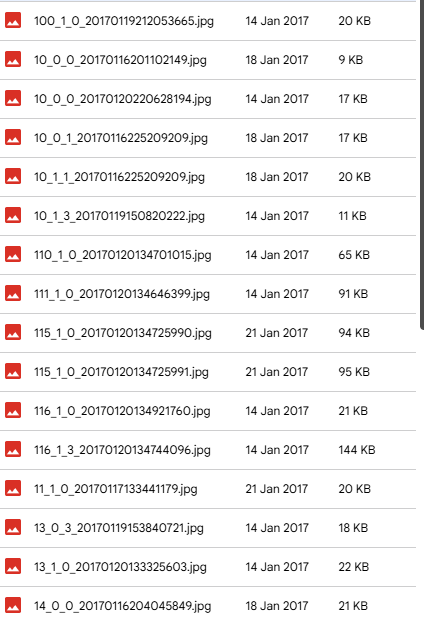

#Importing Libraries

In [1]:
!wget https://hydranets-data.s3.eu-west-3.amazonaws.com/UTKFace.zip

--2025-08-27 01:47:53--  https://hydranets-data.s3.eu-west-3.amazonaws.com/UTKFace.zip
Resolving hydranets-data.s3.eu-west-3.amazonaws.com (hydranets-data.s3.eu-west-3.amazonaws.com)... 52.95.155.68, 3.5.206.14
Connecting to hydranets-data.s3.eu-west-3.amazonaws.com (hydranets-data.s3.eu-west-3.amazonaws.com)|52.95.155.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 131852014 (126M) [application/zip]
Saving to: ‘UTKFace.zip.2’

UTKFace.zip.2       100%[===================>] 125.74M  30.3MB/s    in 5.0s    

2025-08-27 01:47:59 (25.3 MB/s) - ‘UTKFace.zip.2’ saved [131852014/131852014]



In [2]:
!jar xf UTKFace.zip

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import os
import cv2
import glob
from PIL import Image

import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split

In [4]:
image_paths = sorted(glob.glob("UTKFace/*.jpg.chip.jpg"))
print(image_paths[11][8:])

101_0_0_20170112213500903.jpg.chip.jpg


In [5]:
image_paths = sorted(glob.glob("UTKFace/*.jpg.chip.jpg"))
random.shuffle(image_paths)
image_paths = image_paths[:2500]

images = []
ages = []
genders = []
races = []

for path in image_paths:
    filename = path[8:].split("_")
    if len(filename)==4:
        img = Image.open(path).resize((128, 128)).convert("RGB")
        img = np.array(img) / 255.0  # normalize to [0, 1]
        images.append(img)
        ages.append(int(filename[0]))
        genders.append(int(filename[1]))
        races.append(int(filename[2]))



def gender_func(gender_code):
  gender_dict = {0: 'Male', 1: 'Female'}
  return gender_dict[gender_code]

def race_func(race_code):
  race_dict = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}
  return race_dict[race_code]

def ages_recog_func(ages):
    labels = []
    for age in ages:
        if age <= 18:
            labels.append(0)
        elif age <= 60:
            labels.append(1)
        else:
            labels.append(2)
    return labels

ages_list = ages_recog_func(ages)
genders_list = list(map(gender_func, genders))
races_list = list(map(race_func, races))

print(len(images))
for i in range(10):
    print([ages[i],ages_list[i], genders_list[i], races_list[i]]) #we got the Y's

2500
[26, 1, 'Female', 'Indian']
[24, 1, 'Male', 'Others']
[16, 0, 'Male', 'Asian']
[26, 1, 'Female', 'Asian']
[24, 1, 'Male', 'White']
[58, 1, 'Male', 'White']
[65, 2, 'Male', 'White']
[28, 1, 'Male', 'White']
[30, 1, 'Female', 'Indian']
[48, 1, 'Male', 'White']


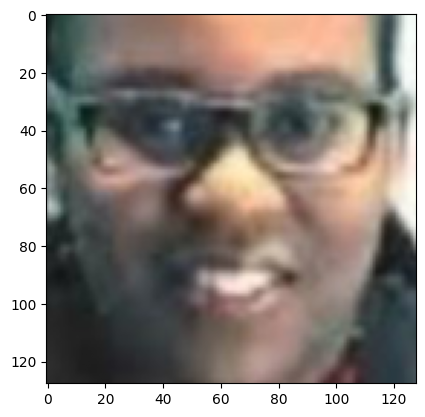

Age: 17
Age: 0
Gender: Male
Race: Black


In [6]:
idx = np.random.randint(len(images))# Hint: Try 19006 for someone who's gonna yell motherfucka at you!

plt.imshow(images[idx])
plt.show()


print("Age: "+ str(ages[idx]))
print("Age: "+ str(ages_list[idx]))
print("Gender: "+ str(genders_list[idx]))
print("Race: "+ str(races_list[idx]))

##Cut them into batches?

[[2215, 695, 1769, 887, 1348, 483, 2190, 526, 199, 314, 1268, 1585, 2298, 772, 1222, 1385, 1383, 400, 896, 1158], [2295, 1627, 2169, 2178, 1811, 580, 213, 1753, 204, 1075, 362, 1673, 594, 2457, 2413, 238, 2268, 1201, 2093, 1930], [2286, 2399, 2183, 487, 965, 501, 1412, 147, 489, 830, 1933, 638, 1107, 644, 1626, 1971, 913, 1968, 1117, 2370], [884, 1216, 2438, 309, 1166, 775, 2191, 1490, 1773, 2327, 10, 198, 1885, 1667, 2292, 2447, 292, 1849, 1482, 2279], [1628, 994, 1781, 511, 861, 1506, 982, 2130, 667, 1366, 1610, 1122, 1554, 2354, 1085, 101, 2049, 924, 9, 1791], [1917, 1280, 1308, 1982, 1931, 2379, 686, 2051, 802, 1392, 60, 1315, 1972, 457, 623, 252, 1637, 790, 1286, 1504], [900, 1978, 448, 1556, 783, 111, 1272, 1110, 37, 779, 691, 1259, 461, 515, 1321, 1119, 1581, 1958, 980, 2464], [462, 2293, 1212, 2185, 55, 2463, 2491, 1327, 188, 597, 607, 1666, 786, 853, 1295, 331, 1815, 1743, 1744, 467], [1901, 2332, 2478, 1998, 750, 2246, 1831, 1541, 725, 2264, 2055, 1069, 865, 1797, 288, 654, 2

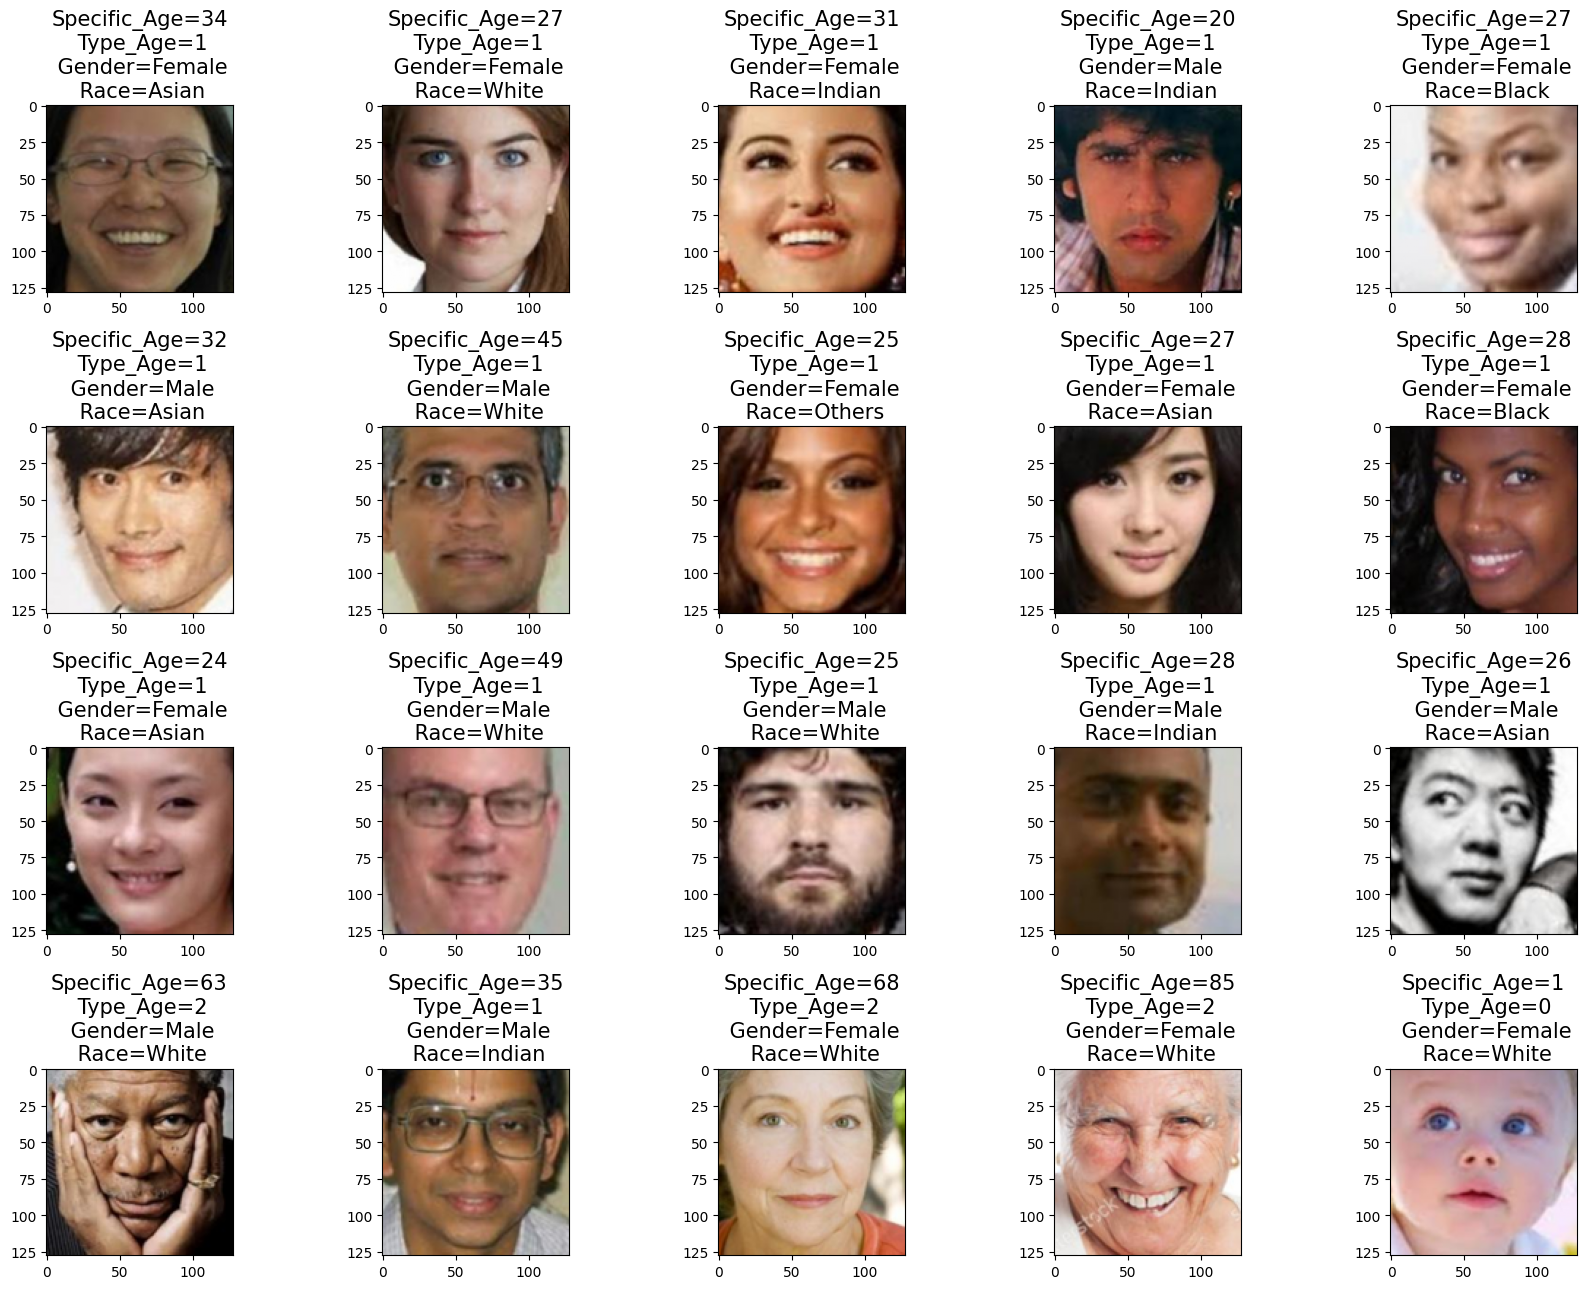

In [7]:
def split_into_batches(lst, batch_size):
    return [lst[i:(i + batch_size)] for i in range(0, len(lst), batch_size)]

import random

data = list(range(0,len(images)+1))
random.shuffle(data)
batches = split_into_batches(data, batch_size=20)##################################################

print(batches[:10])

plt.figure(figsize=(17, 13))
for idx, value in enumerate(batches[0]):
  plt.subplot(4, 5, idx + 1)
  plt.imshow(images[value])
  plt.title(f"Specific_Age={str(ages[value])}\n Type_Age={str(ages_list[value])}\n Gender={str(genders_list[value])}\n Race={str(races_list[value])}" , fontsize=15)
plt.tight_layout()
plt.show()

#Neural Network/Predicting Progress

##Analysis

##Ages---Ages Type Prediction

In [8]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split

print("Original image count:", len(images))
print("Original label count:", len(ages_list))

min_len = min(len(images), len(ages_list))
images = np.array(images[:min_len])
ages_list = np.array(ages_list[:min_len])

print("Aligned image count:", len(images))
print("Aligned label count:", len(genders_list))


x_train, x_test, y_train, y_test = train_test_split(images, ages_list, test_size=0.2, random_state=42)

y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

age_model = models.Sequential([
    layers.Conv2D(32, kernel_size=3, padding='same',activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(pool_size=2), # -> (64, 64, 32)

    layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=2),# -> (32,32,64)

    layers.Conv2D(128,kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=2),# -> (16,16,128)

    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dense(128,activation='relu'),
    layers.Dense(128,activation='relu'),
    layers.Dense(3, activation='softmax')
])


age_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

age_model.fit(x_train, y_train, epochs = 10, batch_size=350, validation_data=(x_test,y_test))


Original image count: 2500
Original label count: 2500
Aligned image count: 2500
Aligned label count: 2500
x_train shape: (2000, 128, 128, 3)
y_train shape: (2000, 3)
x_test shape: (500, 128, 128, 3)
y_test shape: (500, 3)
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 90s 15s/step - accuracy: 0.6152 - loss: 1.0769 - val_accuracy: 0.7220 - val_loss: 0.8253
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 139s 14s/step - accuracy: 0.7267 - loss: 0.7873 - val_accuracy: 0.7220 - val_loss: 0.8175
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 80s 13s/step - accuracy: 0.7216 - loss: 0.7693 - val_accuracy: 0.7220 - val_loss: 0.7899
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 76s 13s/step - accuracy: 0.7227 - loss: 0.7426 - val_accuracy: 0.7220 - val_loss: 0.7557
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 78s 13s/step - accuracy: 0.7206 - loss: 0.7208 - val_accuracy: 0.7220 - val_loss: 0.7445
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 90s 15s/step - accuracy: 0.7300 - loss: 0.6882 - val_accuracy: 0.7460 - val_loss: 0.7073
Epoch 7/10
6/6 ━━━━━━━━━━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step
[0.02796209 0.71587837 0.2561595 ]
1


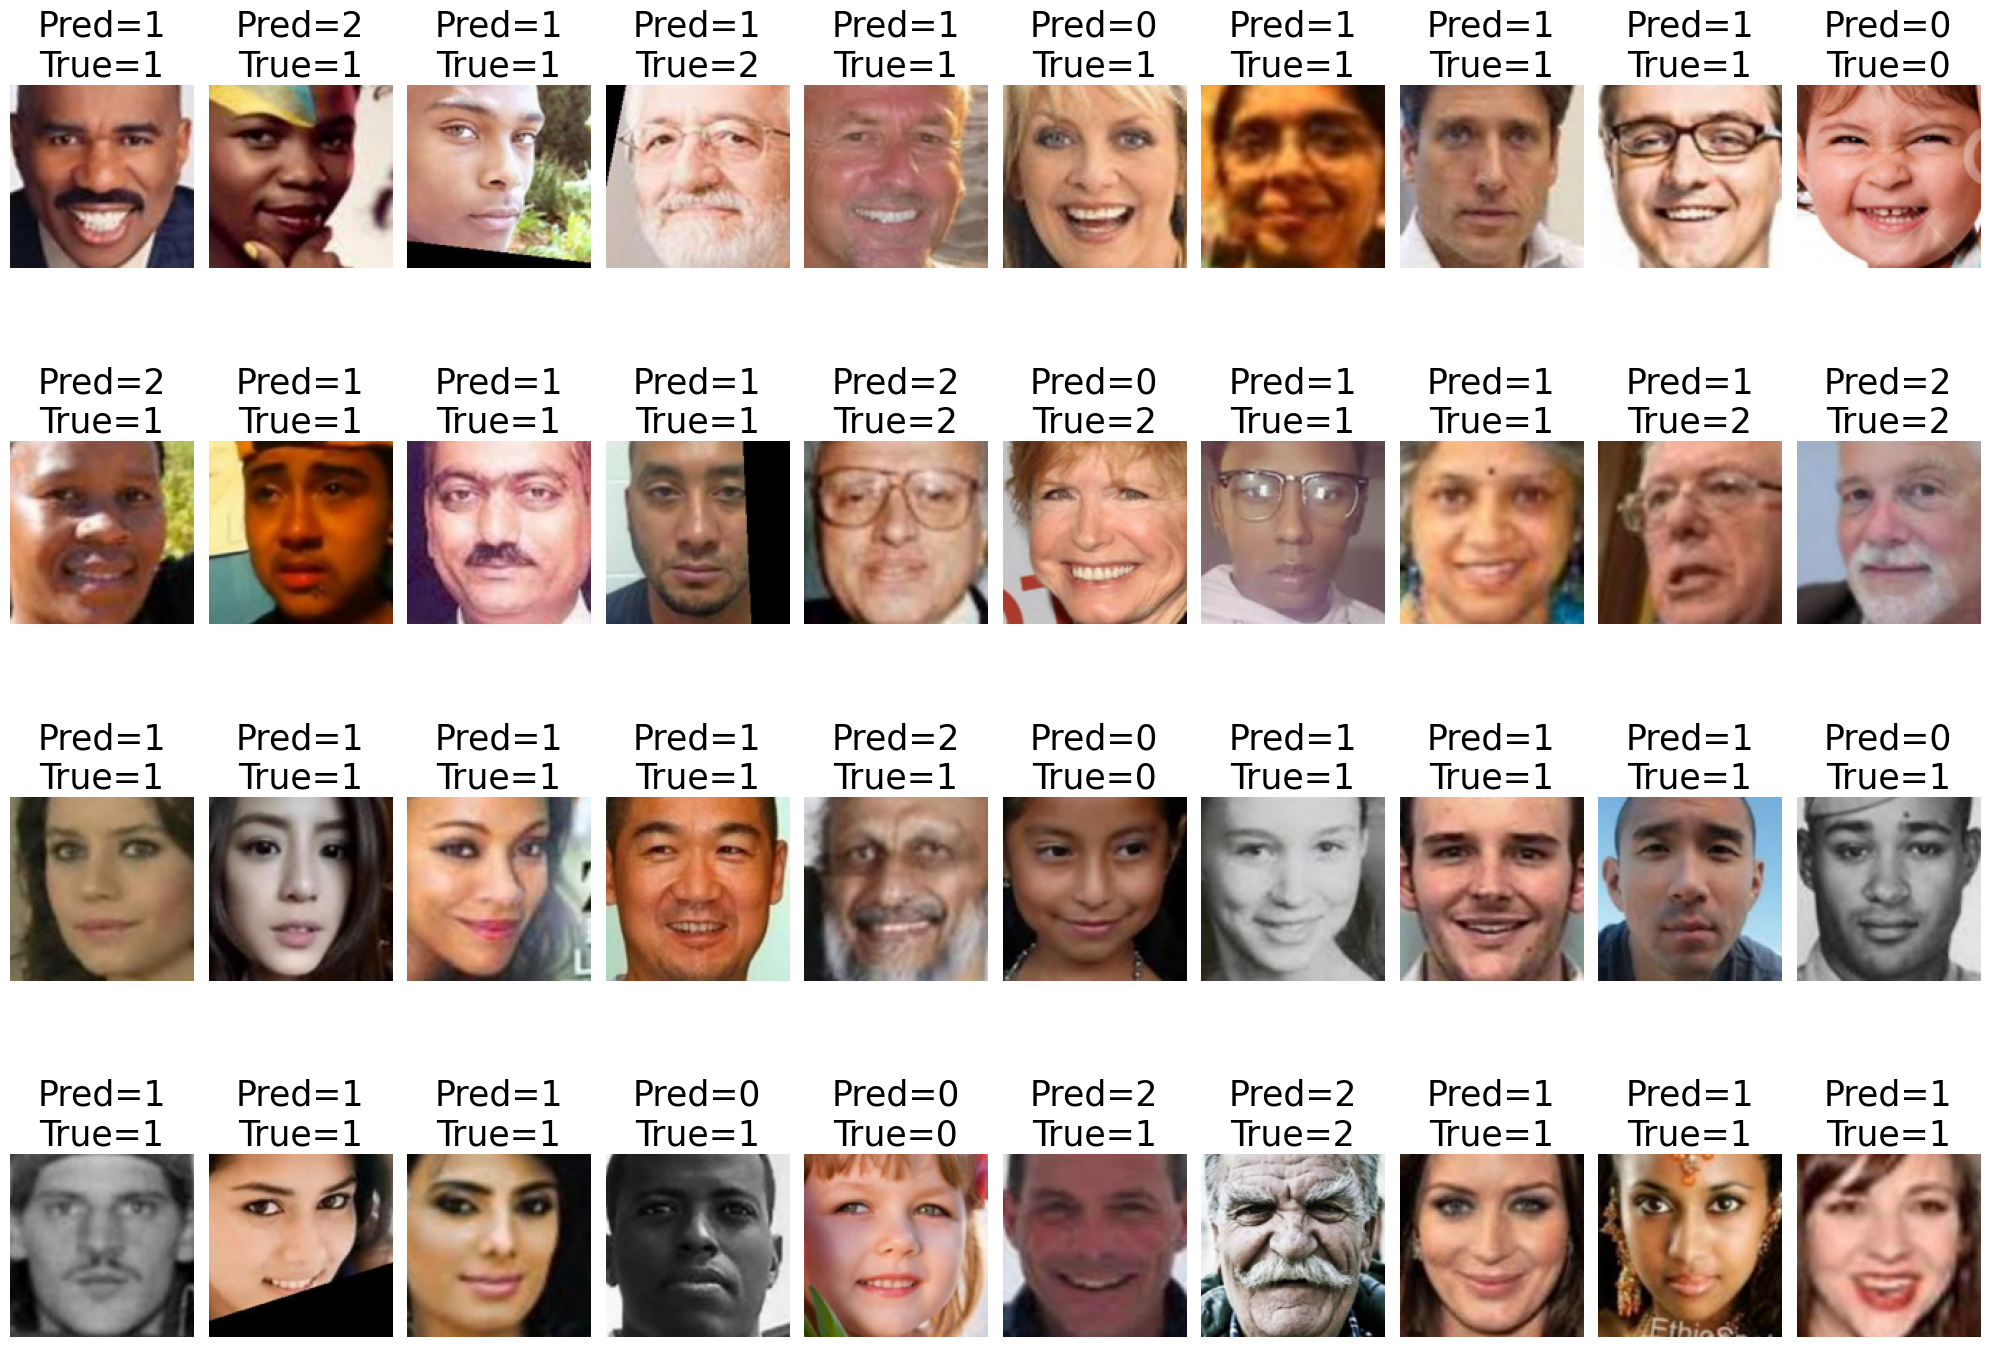

In [9]:
predictions = age_model.predict(x_test)
print(predictions[0])

prediction_labels = predictions[0].argmax()
print(prediction_labels)

num_samples = 40
true_labels = np.argmax(y_test[:num_samples], axis = 1)
predicted_labels = np.argmax(predictions[:num_samples], axis = 1)


plt.figure(figsize=(20, 15))
for i in range(num_samples):
    plt.subplot(4, 10, i + 1)  # 2 rows, 10 images per row
    plt.imshow(x_test[i])
    plt.title(f"Pred={predicted_labels[i]}\nTrue={true_labels[i]}", fontsize=25)
    plt.axis('off')

plt.tight_layout()
plt.show()

#Genders

Original image count: 2500
Original label count: 2500
Aligned image count: 2500
Aligned label count: 2500
x_train shape: (2000, 128, 128, 3)
y_train shape: (2000, 2)
x_test shape: (500, 128, 128, 3)
y_test shape: (500, 2)
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 91s 13s/step - accuracy: 0.4817 - loss: 0.7567 - val_accuracy: 0.6160 - val_loss: 0.6854
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 131s 13s/step - accuracy: 0.6076 - loss: 0.6813 - val_accuracy: 0.6460 - val_loss: 0.6602
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 86s 14s/step - accuracy: 0.6877 - loss: 0.6336 - val_accuracy: 0.6000 - val_loss: 0.7686
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 81s 13s/step - accuracy: 0.6648 - loss: 0.6323 - val_accuracy: 0.6540 - val_loss: 0.6373
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 77s 13s/step - accuracy: 0.6928 - loss: 0.5923 - val_accuracy: 0.7080 - val_loss: 0.5519
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 80s 13s/step - accuracy: 0.7420 - loss: 0.5218 - val_accuracy: 0.7000 - val_loss: 0.5655
Epoch 7/10
6/6 ━━━━━━━━━━━━

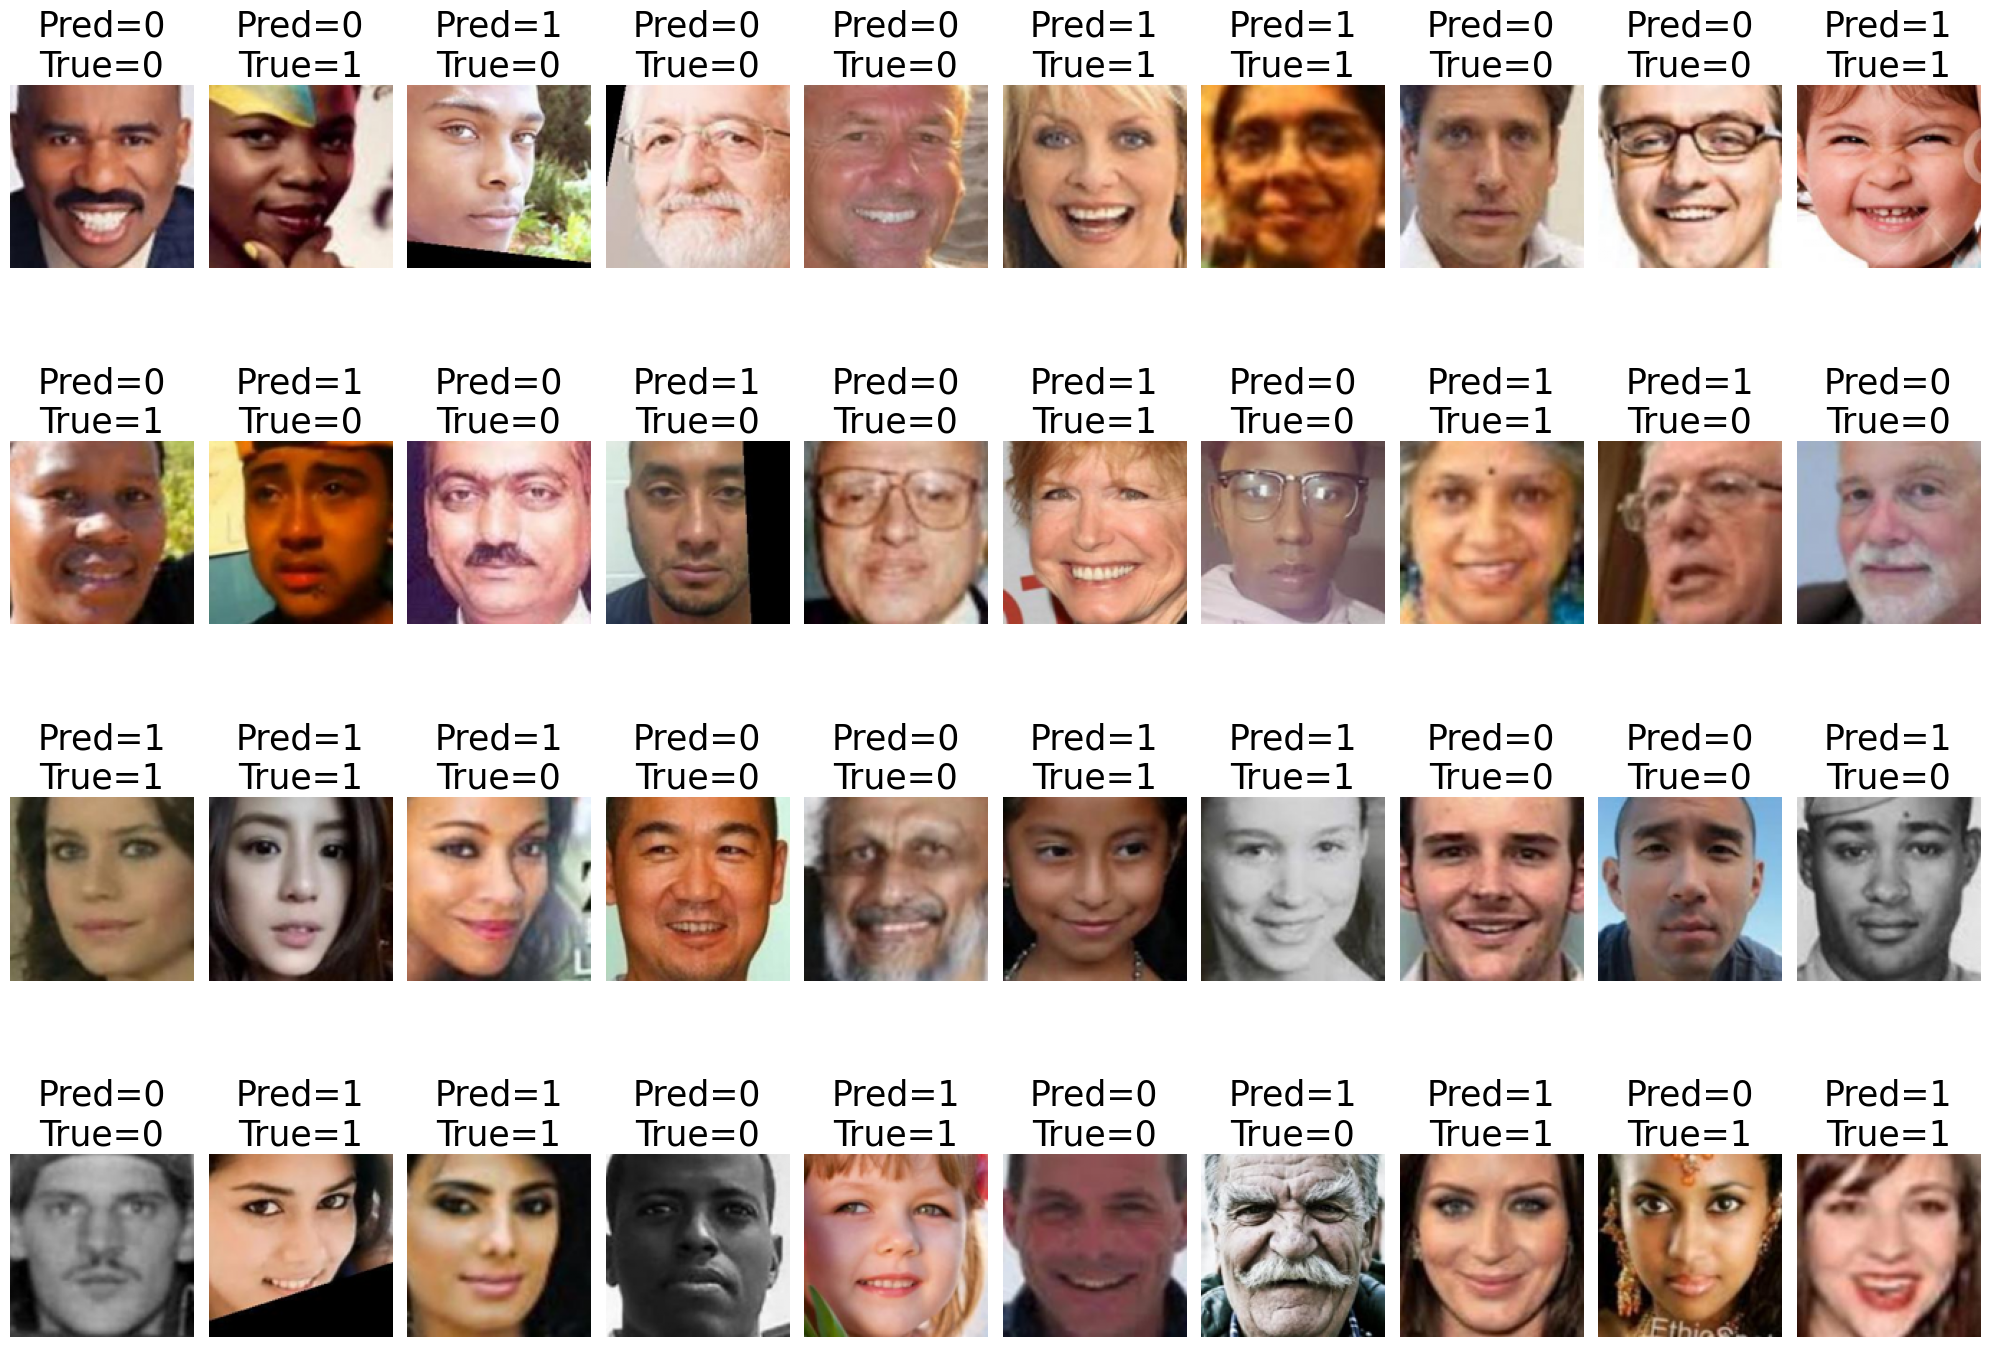

In [11]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split

print("Original image count:", len(images))
print("Original label count:", len(ages_list))

min_len = min(len(images), len(ages_list))
images = np.array(images[:min_len])
ages_list = np.array(ages_list[:min_len])

print("Aligned image count:", len(images))
print("Aligned label count:", len(genders_list))


x_train, x_test, y_train, y_test = train_test_split(images, genders, test_size=0.2, random_state=42)

y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

gender_model = models.Sequential([
    layers.Conv2D(32, kernel_size=3, padding='same',activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(pool_size=2), # -> (64, 64, 32)

    layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=2),# -> (32,32,64)

    layers.Conv2D(128,kernel_size=3, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=2),# -> (16,16,128)

    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dense(128,activation='relu'),
    layers.Dense(128,activation='relu'),
    layers.Dense(2, activation='softmax')
])


gender_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


#_______________________________________________________________________________________________________________


gender_model.fit(x_train, y_train, epochs = 10, batch_size=350, validation_data=(x_test,y_test))

test_loss, test_acc = gender_model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

#______________________________________________________________________________________________________________


predictions = gender_model.predict(x_test)
print(predictions[0])

prediction_labels = predictions[0].argmax()
print(prediction_labels)

num_samples = 40
true_labels = np.argmax(y_test[:num_samples], axis = 1)
predicted_labels = np.argmax(predictions[:num_samples], axis = 1)


plt.figure(figsize=(20, 15))
for i in range(num_samples):
    plt.subplot(4, 10, i + 1)  # 2 rows, 10 images per row
    plt.imshow(x_test[i])
    plt.title(f"Pred={predicted_labels[i]}\nTrue={true_labels[i]}", fontsize=25)
    plt.axis('off')

plt.tight_layout()
plt.show()